In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import weibull_min
from scipy.special import gamma

# Apple-inspired color palette
APPLE_GRAY   = "#1d1d1f"
APPLE_BLUE   = "#0071e3"
APPLE_GREEN  = "#34c759"
APPLE_RED    = "#ff3b30"
APPLE_SILVER = "#f5f5f7"
APPLE_ORANGE = "#ff9500"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   APPLE_SILVER,
    "axes.edgecolor":   APPLE_GRAY,
    "axes.labelcolor":  APPLE_GRAY,
    "xtick.color":      APPLE_GRAY,
    "ytick.color":      APPLE_GRAY,
    "text.color":       APPLE_GRAY,
    "font.family":      "sans-serif",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

print("✅ Libraries loaded. Ready for analysis.")

✅ Libraries loaded. Ready for analysis.


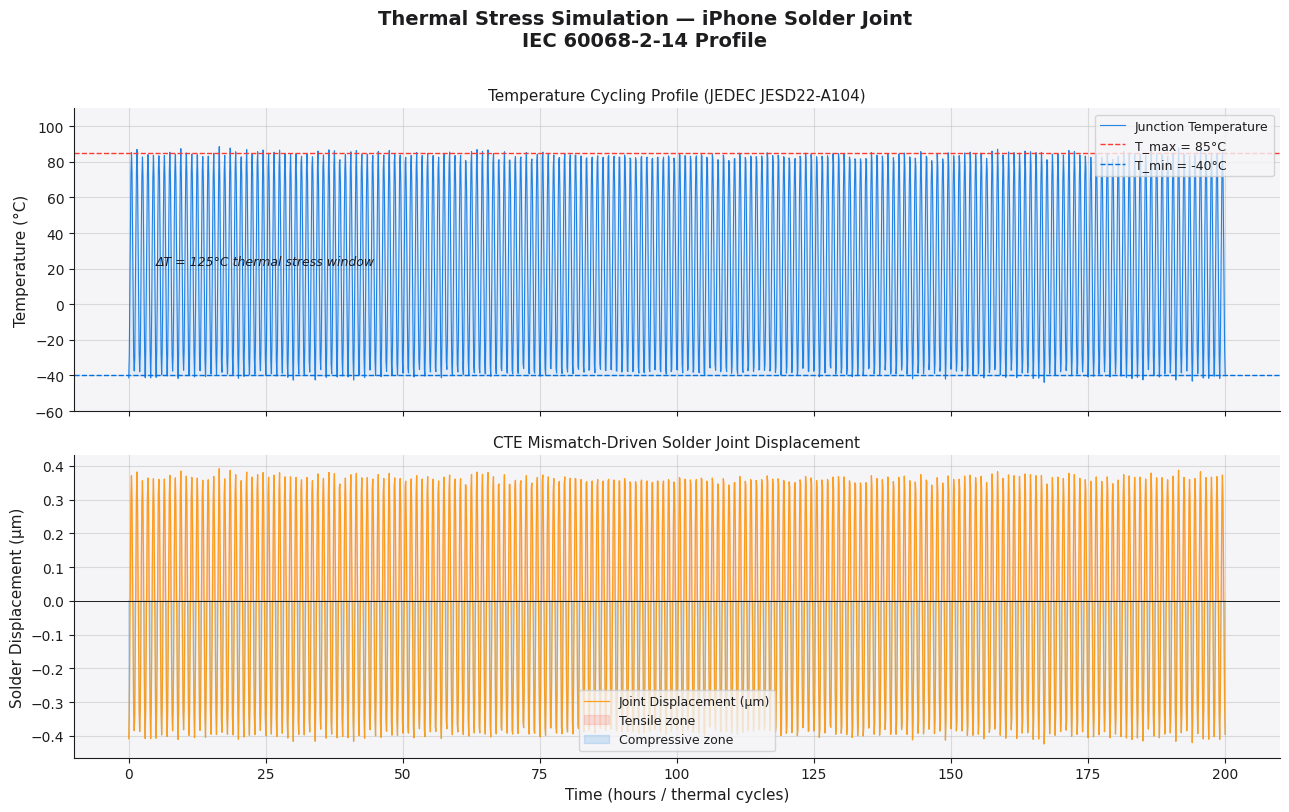

✅ Plot 1 saved.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle("Thermal Stress Simulation — iPhone Solder Joint\nIEC 60068-2-14 Profile",
             fontsize=14, fontweight="bold", color=APPLE_GRAY, y=1.01)

# Time axis: 200 thermal cycles
t = np.linspace(0, 200, 2000)
cycle_period = 1.0  # 1 hour per cycle

# Temperature profile: -40°C to +85°C (JEDEC JESD22-A104 standard)
T_min, T_max = -40, 85
T = T_min + (T_max - T_min) * 0.5 * (1 - np.cos(2 * np.pi * t / cycle_period))
# Add realistic ramp noise
T += np.random.normal(0, 1.5, size=t.shape)

# Thermal expansion (CTE mismatch: silicon ~2.6 ppm/°C, FR4 ~18 ppm/°C)
# Solder joint absorbs the differential strain
CTE_solder   = 25e-6   # ppm/°C for SAC305 solder
CTE_diff     = 15.4e-6 # Effective CTE mismatch (substrate - die)
joint_length = 0.4e-3  # 400 µm typical BGA pitch
delta_T      = T - 25  # Reference temp 25°C
expansion    = CTE_diff * joint_length * delta_T * 1e6  # in microns

# Accumulated plastic strain (simplified Coffin-Manson proxy)
# Each cycle adds irreversible micro-damage
cycle_indices = np.arange(1, 201)
delta_T_range = T_max - T_min
gamma_p = 0.02 * (delta_T_range / 100) ** 1.9  # plastic strain per cycle
cumulative_strain = np.cumsum([gamma_p * (1 + 0.002 * i) for i in range(200)])

# ── Top plot: Temperature profile ──
ax1 = axes[0]
ax1.plot(t, T, color=APPLE_BLUE, linewidth=0.8, alpha=0.85, label="Junction Temperature")
ax1.axhline(T_max, color=APPLE_RED, linestyle="--", linewidth=1, label=f"T_max = {T_max}°C")
ax1.axhline(T_min, color=APPLE_BLUE, linestyle="--", linewidth=1, label=f"T_min = {T_min}°C")
ax1.fill_between(t, T_min, T, alpha=0.08, color=APPLE_BLUE)
ax1.set_ylabel("Temperature (°C)", fontsize=11)
ax1.set_title("Temperature Cycling Profile (JEDEC JESD22-A104)", fontsize=11)
ax1.legend(fontsize=9, loc="upper right")
ax1.set_ylim(-60, 110)
ax1.annotate("ΔT = 125°C thermal stress window", xy=(5, 22), fontsize=9,
             color=APPLE_GRAY, style="italic")

# ── Bottom plot: Solder joint expansion/contraction ──
ax2 = axes[1]
ax2.plot(t, expansion, color=APPLE_ORANGE, linewidth=0.9, alpha=0.85,
         label="Joint Displacement (µm)")
ax2.fill_between(t, 0, expansion, where=(expansion > 0),
                 alpha=0.15, color=APPLE_RED, label="Tensile zone")
ax2.fill_between(t, expansion, 0, where=(expansion < 0),
                 alpha=0.15, color=APPLE_BLUE, label="Compressive zone")
ax2.axhline(0, color=APPLE_GRAY, linewidth=0.7, linestyle="-")
ax2.set_ylabel("Solder Displacement (µm)", fontsize=11)
ax2.set_xlabel("Time (hours / thermal cycles)", fontsize=11)
ax2.set_title("CTE Mismatch-Driven Solder Joint Displacement", fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plot1_thermal_stress.png", dpi=180, bbox_inches="tight")
plt.show()
print("✅ Plot 1 saved.")

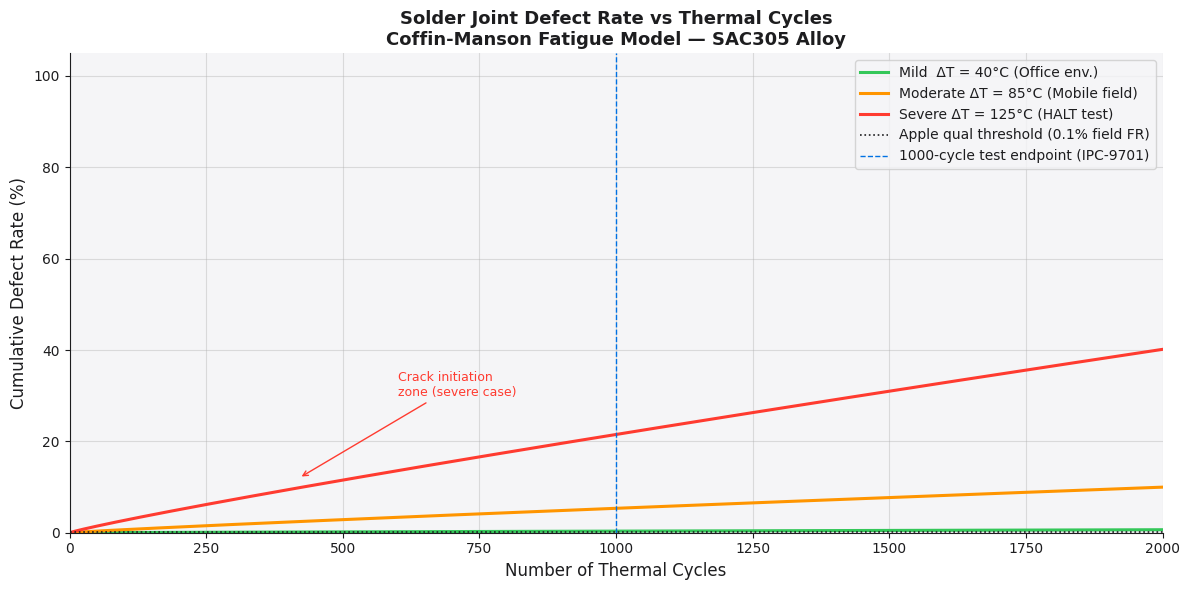

✅ Plot 2 saved.


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

cycles = np.linspace(1, 2000, 500)

# Coffin-Manson relationship: Nf = C / (ΔT)^n
# For SAC305 solder: n ≈ 1.9, adjusted for different stress amplitudes
def failure_rate(N, C, n, delta_T):
    """Coffin-Manson fatigue failure rate model"""
    Nf = C / (delta_T ** n)          # characteristic life
    rate = (n / Nf) * (N / Nf)**(n-1) # Weibull-Coffin hybrid rate
    return np.clip(rate * 100, 0, 100)

# Three severity scenarios
scenarios = [
    {"label": "Mild  ΔT = 40°C (Office env.)",    "C": 8e5, "n": 1.9, "dT": 40,  "color": APPLE_GREEN},
    {"label": "Moderate ΔT = 85°C (Mobile field)", "C": 8e5, "n": 1.9, "dT": 85,  "color": APPLE_ORANGE},
    {"label": "Severe ΔT = 125°C (HALT test)",     "C": 8e5, "n": 1.9, "dT": 125, "color": APPLE_RED},
]

for s in scenarios:
    rate = failure_rate(cycles, s["C"], s["n"], s["dT"])
    ax.plot(cycles, rate, color=s["color"], linewidth=2.2, label=s["label"])

# Mark Apple's internal qualification threshold (conceptual)
ax.axhline(y=0.1, color=APPLE_GRAY, linestyle=":", linewidth=1.2,
           label="Apple qual threshold (0.1% field FR)")
ax.axvline(x=1000, color=APPLE_BLUE, linestyle="--", linewidth=1,
           label="1000-cycle test endpoint (IPC-9701)")

ax.set_xlabel("Number of Thermal Cycles", fontsize=12)
ax.set_ylabel("Cumulative Defect Rate (%)", fontsize=12)
ax.set_title("Solder Joint Defect Rate vs Thermal Cycles\nCoffin-Manson Fatigue Model — SAC305 Alloy",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 2000)
ax.set_ylim(0, 105)

# Annotate inflection zone
ax.annotate("Crack initiation\nzone (severe case)",
            xy=(420, 12), xytext=(600, 30),
            arrowprops=dict(arrowstyle="->", color=APPLE_RED),
            fontsize=9, color=APPLE_RED)

plt.tight_layout()
plt.savefig("plot2_defect_rate.png", dpi=180, bbox_inches="tight")
plt.show()
print("✅ Plot 2 saved.")

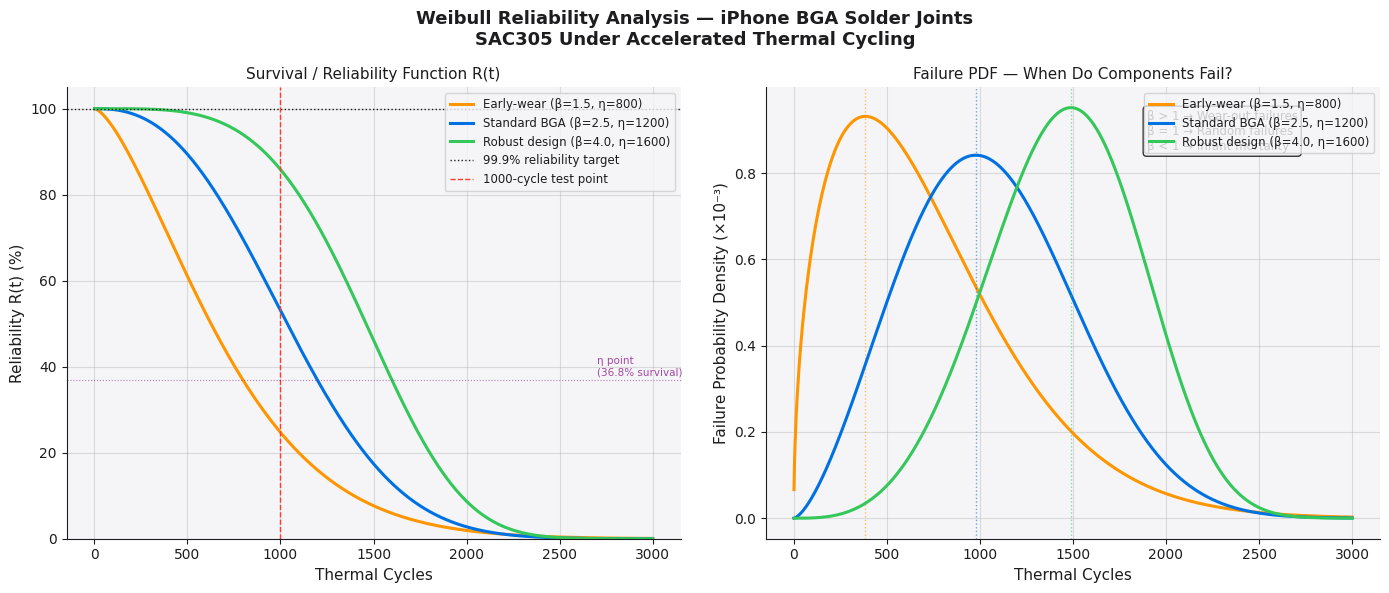

✅ Plot 3 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Weibull Reliability Analysis — iPhone BGA Solder Joints\nSAC305 Under Accelerated Thermal Cycling",
             fontsize=13, fontweight="bold", color=APPLE_GRAY)

# Weibull parameters (realistic for BGA solder under JEDEC cycling)
# β = shape (wear-out mode), η = scale (characteristic life in cycles)
params = [
    {"beta": 1.5, "eta": 800,  "label": "Early-wear (β=1.5, η=800)",   "color": APPLE_ORANGE},
    {"beta": 2.5, "eta": 1200, "label": "Standard BGA (β=2.5, η=1200)","color": APPLE_BLUE},
    {"beta": 4.0, "eta": 1600, "label": "Robust design (β=4.0, η=1600)","color": APPLE_GREEN},
]

t_range = np.linspace(1, 3000, 1000)

# ── Left: Reliability R(t) = 1 - F(t) ──
ax1 = axes[0]
for p in params:
    R = np.exp(-(t_range / p["eta"]) ** p["beta"])
    ax1.plot(t_range, R * 100, color=p["color"], linewidth=2.2, label=p["label"])

ax1.axhline(99.9, color=APPLE_GRAY, linestyle=":", linewidth=1, label="99.9% reliability target")
ax1.axvline(1000, color=APPLE_RED, linestyle="--", linewidth=1, label="1000-cycle test point")

# Mark η (63.2% survival = 36.8% failure point)
ax1.axhline(36.8, color="purple", linestyle=":", linewidth=0.8, alpha=0.5)
ax1.text(2700, 38, "η point\n(36.8% survival)", fontsize=7.5, color="purple", alpha=0.7)

ax1.set_xlabel("Thermal Cycles", fontsize=11)
ax1.set_ylabel("Reliability R(t) (%)", fontsize=11)
ax1.set_title("Survival / Reliability Function R(t)", fontsize=11)
ax1.legend(fontsize=8.5)
ax1.set_ylim(0, 105)

# ── Right: Failure PDF (when do failures peak?) ──
ax2 = axes[1]
for p in params:
    # Weibull PDF: f(t) = (β/η) * (t/η)^(β-1) * exp(-(t/η)^β)
    f = (p["beta"] / p["eta"]) * (t_range / p["eta"])**(p["beta"] - 1) * \
        np.exp(-(t_range / p["eta"])**p["beta"])
    ax2.plot(t_range, f * 1000, color=p["color"], linewidth=2.2, label=p["label"])

    # Mark the mode (peak failure time)
    t_mode = p["eta"] * ((p["beta"] - 1) / p["beta"])**(1 / p["beta"]) if p["beta"] > 1 else 0
    f_mode = (p["beta"] / p["eta"]) * (t_mode / p["eta"])**(p["beta"] - 1) * \
             np.exp(-(t_mode / p["eta"])**p["beta"])
    ax2.axvline(t_mode, color=p["color"], linestyle=":", linewidth=1, alpha=0.6)

ax2.set_xlabel("Thermal Cycles", fontsize=11)
ax2.set_ylabel("Failure Probability Density (×10⁻³)", fontsize=11)
ax2.set_title("Failure PDF — When Do Components Fail?", fontsize=11)
ax2.legend(fontsize=8.5)

# Annotation box
textstr = "β > 1 → Wear-out failures\nβ = 1 → Random failures\nβ < 1 → Infant mortality"
props = dict(boxstyle="round", facecolor=APPLE_SILVER, alpha=0.8)
ax2.text(0.62, 0.95, textstr, transform=ax2.transAxes, fontsize=8.5,
         verticalalignment="top", bbox=props, color=APPLE_GRAY)

plt.tight_layout()
plt.savefig("plot3_weibull.png", dpi=180, bbox_inches="tight")
plt.show()
print("✅ Plot 3 saved.")

In [7]:
print("\n" + "="*58)
print("  WEIBULL RELIABILITY SUMMARY — BGA SOLDER JOINT ANALYSIS")
print("="*58)
print(f"{'Scenario':<25} {'β':>5} {'η (cycles)':>11} {'B10 Life':>10} {'MTTF':>10}")
print("-"*58)

for p in params:
    beta, eta = p["beta"], p["eta"]
    # B10 = cycles at which 10% have failed
    B10 = eta * (-np.log(0.90)) ** (1/beta)
    # MTTF = η * Γ(1 + 1/β)
    MTTF = eta * gamma(1 + 1/beta)
    print(f"{p['label'][:24]:<25} {beta:>5.1f} {eta:>11} {B10:>10.0f} {MTTF:>10.0f}")

print("-"*58)
print("  B10 Life = cycles when 10% of population has failed")
print("  MTTF = Mean Time To Failure (in equivalent cycles)")
print("="*58)
print("\n✅ All 3 plots generated. Export PNG files for your report.")
print("💡 In your report, cite: IPC-9701A, JEDEC JESD22-A104, Coffin-Manson (1954)")



  WEIBULL RELIABILITY SUMMARY — BGA SOLDER JOINT ANALYSIS
Scenario                      β  η (cycles)   B10 Life       MTTF
----------------------------------------------------------
Early-wear (β=1.5, η=800    1.5         800        178        722
Standard BGA (β=2.5, η=1    2.5        1200        488       1065
Robust design (β=4.0, η=    4.0        1600        912       1450
----------------------------------------------------------
  B10 Life = cycles when 10% of population has failed
  MTTF = Mean Time To Failure (in equivalent cycles)

✅ All 3 plots generated. Export PNG files for your report.
💡 In your report, cite: IPC-9701A, JEDEC JESD22-A104, Coffin-Manson (1954)
